In [25]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


In [26]:
#load dataset
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    image_size=(128,128),
    batch_size=32,
    label_mode="categorical",
    shuffle=True
)

validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    image_size=(128,128),
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

print("Class Names:", training_set.class_names)


Found 7000 files belonging to 2 classes.
Found 3000 files belonging to 2 classes.
Class Names: ['fake', 'real']


In [27]:
#normalization
normalization_layer = tf.keras.layers.Rescaling(1./255)

training_set = training_set.map(lambda x, y: (normalization_layer(x), y))
validation_set = validation_set.map(lambda x, y: (normalization_layer(x), y))


In [28]:
# data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [29]:
training_set = training_set.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)


In [30]:
#prefetching
AUTOTUNE = tf.data.AUTOTUNE
training_set = training_set.prefetch(buffer_size=AUTOTUNE)
validation_set = validation_set.prefetch(buffer_size=AUTOTUNE)


In [31]:
#class weights calculation
labels = np.concatenate([y.numpy() for x, y in training_set], axis=0)
labels = np.argmax(labels, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: 1.0, 1: 1.0}


In [32]:
#building the model
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32,3,activation='relu',input_shape=(128,128,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(2,activation='softmax')
])


c:\Users\Gopal Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
#compiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,442 (24.86 MB)

 Trainable params: 6,516,994 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [34]:
#early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [35]:
#training the model
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=30,
    class_weight=class_weights,
    callbacks=early_stop
)


Epoch 1/30


219/219 ━━━━━━━━━━━━━━━━━━━━ 188s 832ms/step - accuracy: 0.5768 - loss: 1.0547 - val_accuracy: 0.5000 - val_loss: 3.9437
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 187s 851ms/step - accuracy: 0.6407 - loss: 0.6431 - val_accuracy: 0.5887 - val_loss: 0.8040
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 178s 812ms/step - accuracy: 0.6661 - loss: 0.6172 - val_accuracy: 0.7087 - val_loss: 0.5746
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 177s 809ms/step - accuracy: 0.6726 - loss: 0.5986 - val_accuracy: 0.7190 - val_loss: 0.5494
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 183s 833ms/step - accuracy: 0.7010 - loss: 0.5828 - val_accuracy: 0.7387 - val_loss: 0.5329
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 179s 816ms/step - accuracy: 0.6995 - loss: 0.5718 - val_accuracy: 0.7083 - val_loss: 0.5622
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 179s 816ms/step - accuracy: 0.7142 - loss: 0.5524 - val_accuracy: 0.7467 - val_loss: 0.5302
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 177s 806ms/step - accuracy: 0.7351 - loss: 0.53

In [36]:
## Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)
print("Training Accuracy:", train_acc)

219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 143ms/step - accuracy: 0.8085 - loss: 0.4195
Training Accuracy: 0.8144285678863525


In [37]:
## Model evaluation on validation set
val_loss, val_acc = model.evaluate(validation_set)
print("Validation Accuracy:", val_acc)


94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.7604 - loss: 0.4966
Validation Accuracy: 0.7850000262260437


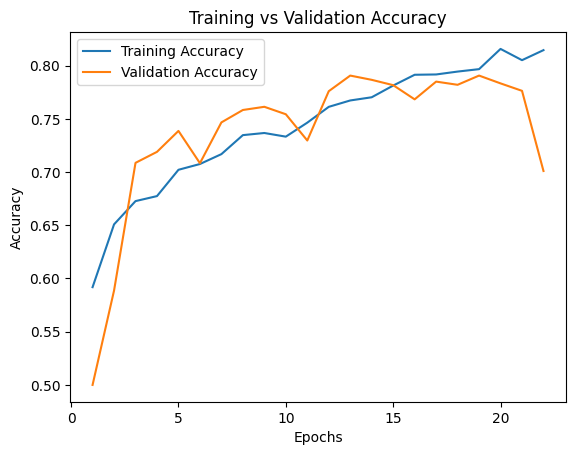

In [38]:
# Plotting training and validation accuracy graph
epochs = range(1,len(history.history['accuracy'])+1)

plt.plot(epochs, history.history['accuracy'], label="Training Accuracy")
plt.plot(epochs, history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


In [39]:
#saving the model
model.save("final_fake_face_model.h5")
model.save("Trained_model.keras")


In [40]:
history.history

{'accuracy': [0.5918571352958679,
  0.650857150554657,
  0.6727142930030823,
  0.6774285435676575,
  0.7021428346633911,
  0.7075714468955994,
  0.7168571352958679,
  0.7347142696380615,
  0.7367143034934998,
  0.7332857251167297,
  0.7464285492897034,
  0.7612857222557068,
  0.7672857046127319,
  0.7702857255935669,
  0.7812857031822205,
  0.7914285659790039,
  0.7917143106460571,
  0.7944285869598389,
  0.7967143058776855,
  0.8157142996788025,
  0.805142879486084,
  0.8145714402198792],
 'loss': [0.8059262633323669,
  0.6331689953804016,
  0.6099569201469421,
  0.5977572798728943,
  0.5754296779632568,
  0.5647058486938477,
  0.5481606721878052,
  0.5325113534927368,
  0.5310680866241455,
  0.5249444246292114,
  0.5101112723350525,
  0.49656441807746887,
  0.4835648834705353,
  0.4796210527420044,
  0.46707597374916077,
  0.4441738426685333,
  0.4412021338939667,
  0.4396683871746063,
  0.4347693622112274,
  0.4092724621295929,
  0.4244183301925659,
  0.40937408804893494],
 'val_acc

In [41]:
## Recording history in json Formate
import json
with open("training_hist.json","w") as f:
    json.dump(history.history,f)

In [42]:
#Test set
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128,128),
    shuffle=False
)

Found 3000 files belonging to 2 classes.


In [43]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step


In [44]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)
Y_true

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step


<tf.Tensor: shape=(3000,), dtype=int64, numpy=array([0, 0, 0, ..., 1, 1, 1], dtype=int64)>

In [45]:
predicted_categories

<tf.Tensor: shape=(3000,), dtype=int64, numpy=array([1, 1, 1, ..., 1, 1, 1], dtype=int64)>

In [46]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

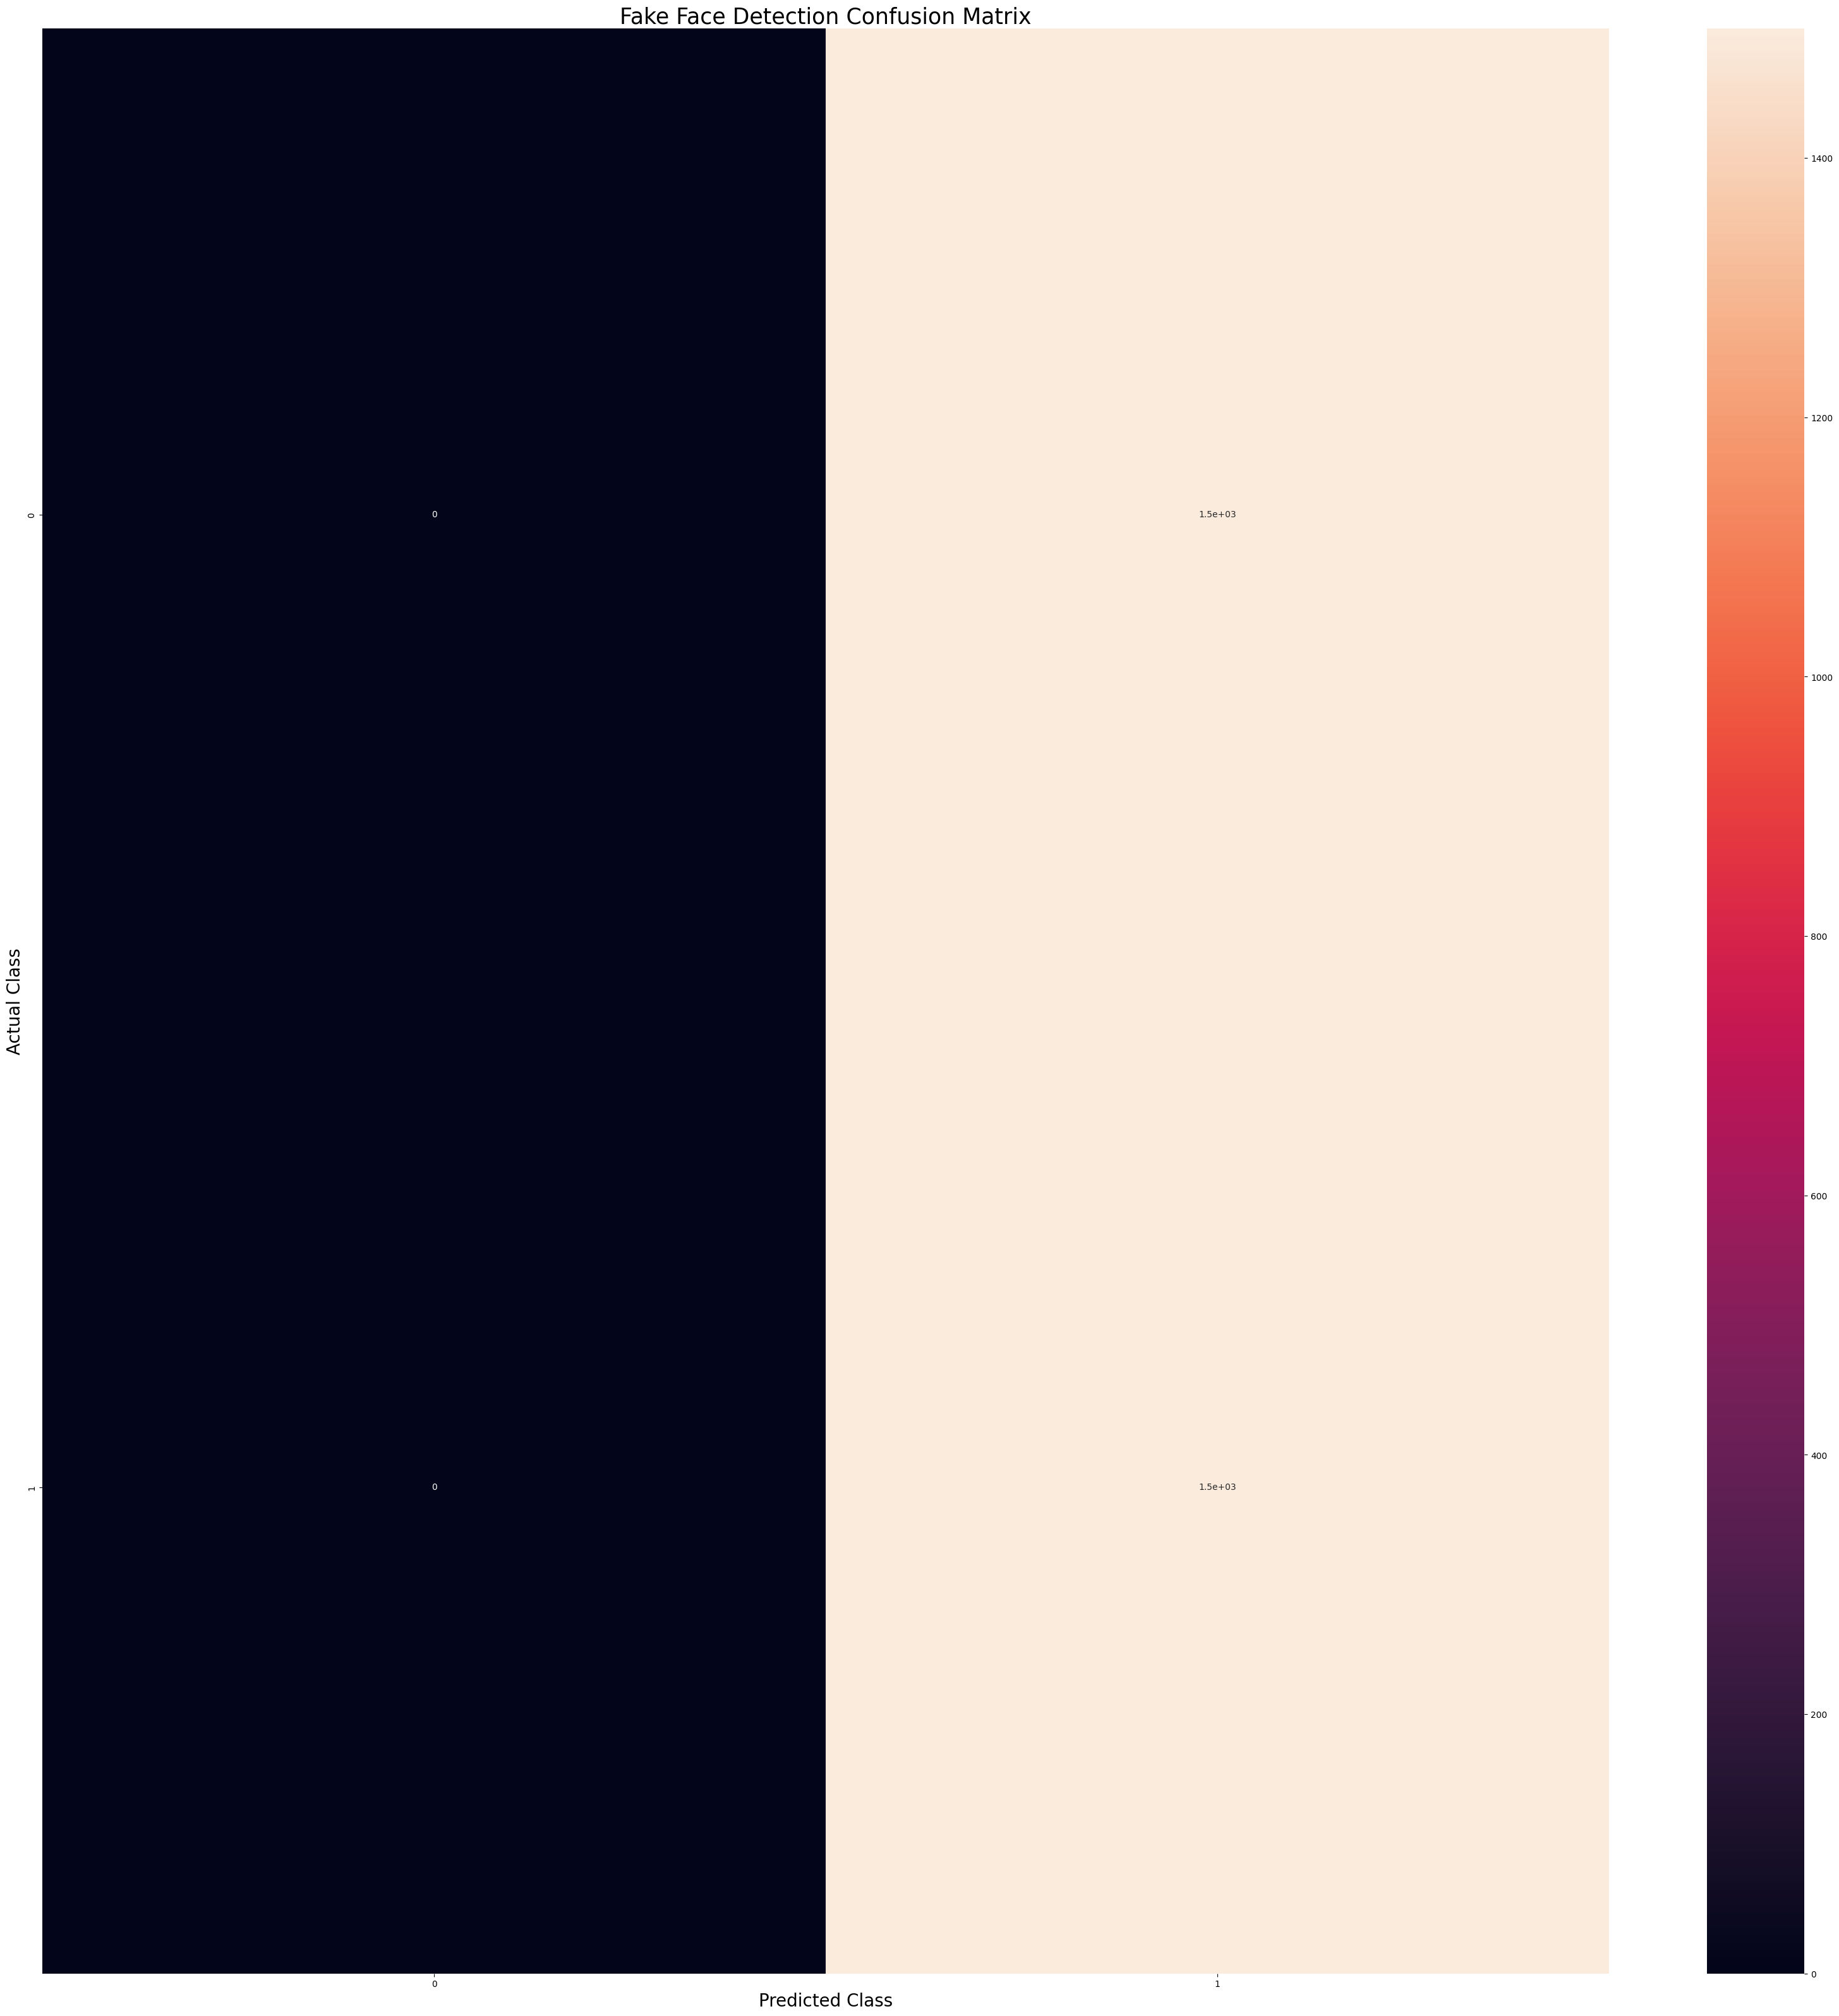

In [47]:
# confusion matrix visualization
import seaborn as sns
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Fake Face Detection Confusion Matrix',fontsize = 25)
plt.show()